# GC-IMS — Random Forest Classifier Evaluation
**Protocols:** TRTR (baseline) → TSTR+ ratio sweep per model  
**Models:** cWGAN-GP · cWGAN · cGAN · WGAN-GP  
**Task:** 4-class pure-culture classification (lb / ec / sc / pf)  
**Metrics:** Accuracy · macro-F1 · TP · TN · FP · FN per class

> Only **pure-culture** samples are used for RF evaluation.  
> Mixed-culture spectra are excluded — they are a separate, harder problem.

## Imports

In [31]:
import warnings; warnings.filterwarnings("ignore")
from collections import Counter
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              classification_report)
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 9,
                     "axes.titlesize": 10, "figure.facecolor": "white"})
print("imports ok")


imports ok


## 1 · Configuration — edit paths here

In [32]:
# ── file paths ───────────────────────────────────────────────────────────────
REAL_CACHE = "ims_cache.h5"

MODEL_CACHES = {
    "cWGAN-GP": "synthetic_cwgan_gp.h5",
    "cWGAN":    "synthetic_cwgan.h5",
    "cGAN":     "synthetic_cgan.h5",
    "WGAN-GP":  "synthetic_wgan_gp.h5",
}

# ── RF ────────────────────────────────────────────────────────────────────────
RF_TREES  = 300
PEAK_THR  = 0.05

# ── ratio sweep ───────────────────────────────────────────────────────────────
RATIOS   = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0]
N_SEEDS  = 5

# ── task: pure-culture 4-class classification ─────────────────────────────────
ORGANISMS   = ["lb", "ec", "sc", "pf"]
LABEL_NAMES = ORGANISMS          # only pure cultures in classifier
VAL_BATCH   = 4                  # held-out batch index

MODEL_COLORS = {
    "cWGAN-GP": "#2e7d9e",
    "cWGAN":    "#e07b39",
    "cGAN":     "#5aab61",
    "WGAN-GP":  "#9b59b6",
}

# ── global results storage (populated as model cells run) ─────────────────────
ALL_SWEEPS = {}   # model → {ratio: (mean_acc, std_acc)}
ALL_BEST_M = {}   # model → metrics dict at best ratio
ALL_BEST_R = {}   # model → best ratio float
TRTR_METRICS = None
TRTR_ACC     = None

print("Config loaded.")


Config loaded.


## 2 · Shared functions

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Label helpers
# ─────────────────────────────────────────────────────────────────────────────

def is_pure(org_vec):
    """Return True if exactly one organism bit is active (pure culture)."""
    return int(np.sum(org_vec > 0.5)) == 1

def org_vec_to_label(org_vec):
    """4-dim one-hot → organism string, e.g. [0,1,0,0] → 'ec'."""
    idx = int(np.argmax(org_vec))
    return ORGANISMS[idx]

# ─────────────────────────────────────────────────────────────────────────────
# Data loading — pure-culture only
# ─────────────────────────────────────────────────────────────────────────────

def load_cache(path, target_shape=None, pure_only=True):
    """
    Load spectra from an HDF5 cache.
    pure_only=True  → skip any sample where more than one org_vec bit is active.
    Returns X (N,H,W), y (N,) label strings, canon shape.
    """
    with h5py.File(path, "r") as hf:
        keys = sorted(k for k in hf.keys() if k.startswith("sample_"))
        if not keys:
            keys = [k for k in hf.keys() if "values" in hf[k]]

        if target_shape is None:
            if "height" in hf.attrs and "width" in hf.attrs:
                target_shape = (int(hf.attrs["height"]), int(hf.attrs["width"]))
            else:
                sh = Counter(tuple(hf[k]["values"].shape) for k in keys)
                target_shape = (max(s[0] for s in sh), max(s[1] for s in sh))

        H, W = target_shape
        X, y, skipped = [], [], 0

        for k in keys:
            grp   = hf[k]
            ov    = grp["org_vec"][:]
            if pure_only and not is_pure(ov):
                skipped += 1
                continue
            arr = grp["values"][:].astype(np.float32)
            p = np.zeros((H, W), dtype=np.float32)
            h, w = arr.shape
            p[:min(h,H), :min(w,W)] = arr[:min(h,H), :min(w,W)]
            X.append(p)
            y.append(org_vec_to_label(ov))

    note = f"(skipped {skipped} mixed)" if skipped else ""
    print(f"  Loaded {Path(path).name}: {len(X)} pure-culture samples  "
          f"shape={target_shape} {note}")
    return np.array(X, dtype=np.float32), np.array(y), target_shape


def load_real_split(cache_path, val_batch=VAL_BATCH):
    """
    Split real data by batch attribute:
      train = all batches except val_batch
      test  = val_batch only
    Falls back to stratified 80/20 if batch attr is missing.
    Returns X_train, y_train, X_test, y_test, canon_shape.
    """
    with h5py.File(cache_path, "r") as hf:
        if "height" in hf.attrs and "width" in hf.attrs:
            target_shape = (int(hf.attrs["height"]), int(hf.attrs["width"]))
        else:
            keys = sorted(k for k in hf.keys() if k.startswith("sample_"))
            sh = Counter(tuple(hf[k]["values"].shape) for k in keys)
            target_shape = (max(s[0] for s in sh), max(s[1] for s in sh))
        H, W = target_shape

        Xtr, ytr, Xte, yte = [], [], [], []
        has_batch = False

        for k in sorted(k for k in hf.keys() if k.startswith("sample_")):
            grp = hf[k]
            ov  = grp["org_vec"][:]
            if not is_pure(ov):
                continue
            arr = grp["values"][:].astype(np.float32)
            p = np.zeros((H, W), dtype=np.float32)
            h, w = arr.shape
            p[:min(h,H), :min(w,W)] = arr[:min(h,H), :min(w,W)]
            lbl = org_vec_to_label(ov)

            if "batch" in grp.attrs:
                has_batch = True
                if int(grp.attrs["batch"]) == val_batch:
                    Xte.append(p); yte.append(lbl)
                else:
                    Xtr.append(p); ytr.append(lbl)
            else:
                Xtr.append(p); ytr.append(lbl)

    if not has_batch or not Xte:
        print("    No batch attr or empty test split — using 80/20 stratified split.")
        Xall, yall = np.array(Xtr, dtype=np.float32), np.array(ytr)
        Xtr_, Xte_, ytr_, yte_ = train_test_split(
            Xall, yall, test_size=0.2, stratify=yall, random_state=42)
        return Xtr_, ytr_, Xte_, yte_, target_shape

    return (np.array(Xtr, dtype=np.float32), np.array(ytr),
            np.array(Xte,  dtype=np.float32), np.array(yte),  target_shape)

# ─────────────────────────────────────────────────────────────────────────────
# Feature extraction
# ─────────────────────────────────────────────────────────────────────────────

def extract_features(X):
    """71-D vector per spectrum: global stats (11) + RT proj (30) + drift proj (30)."""
    feats = []
    for spec in X:
        flat = spec.flatten()
        mask = flat > (PEAK_THR * flat.max())
        f = [
            flat.mean(), flat.std(), flat.max(),
            float(skew(flat)), float(kurtosis(flat)),
            flat[mask].mean() if mask.any() else 0.0,
            flat[mask].std()  if mask.any() else 0.0,
            flat[mask].max()  if mask.any() else 0.0,
            float(mask.sum()),
            np.average(np.arange(spec.shape[0]), weights=spec.sum(axis=1)+1e-9),
            np.average(np.arange(spec.shape[1]), weights=spec.sum(axis=0)+1e-9),
            *spec.max(axis=1)[:30].tolist(),
            *spec.max(axis=0)[:30].tolist(),
        ]
        feats.append(f)
    return np.array(feats, dtype=np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# Metrics
# ─────────────────────────────────────────────────────────────────────────────

def full_metrics(y_true, y_pred, labels=LABEL_NAMES):
    acc = float(accuracy_score(y_true, y_pred))
    f1m = float(f1_score(y_true, y_pred, average="macro",
                          zero_division=0, labels=labels))
    cm  = confusion_matrix(y_true, y_pred, labels=labels)
    n   = len(y_true)
    per = {}
    for i, cls in enumerate(labels):
        tp = int(cm[i,i]); fp = int(cm[:,i].sum()-tp)
        fn = int(cm[i,:].sum()-tp); tn = int(n-tp-fp-fn)
        pr = tp/(tp+fp) if tp+fp else 0.0
        rc = tp/(tp+fn) if tp+fn else 0.0
        f1 = 2*pr*rc/(pr+rc) if pr+rc else 0.0
        per[cls] = dict(TP=tp, TN=tn, FP=fp, FN=fn,
                        precision=pr, recall=rc, f1=f1)
    return dict(accuracy=acc, f1_macro=f1m, cm=cm, per_class=per)


def train_eval(Xtr, ytr, Xte, yte, seed=42):
    clf = RandomForestClassifier(n_estimators=RF_TREES, n_jobs=-1,
                                  min_samples_leaf=2, random_state=seed)
    clf.fit(extract_features(Xtr), ytr)
    yp = clf.predict(extract_features(Xte))
    return full_metrics(yte, yp)


def ratio_sweep(Xtr, ytr, Xsyn, ysyn, Xte, yte):
    """Sweep RATIOS, average over N_SEEDS. Returns {ratio: (mean_acc, std_acc)}."""
    Fte = extract_features(Xte)
    out = {}
    for r in RATIOS:
        ns   = int(len(Xtr) * r)
        accs = []
        for seed in range(N_SEEDS):
            np.random.seed(seed)
            if ns == 0:
                Xa, ya = Xtr, ytr
            elif ns <= len(Xsyn):
                idx = np.random.choice(len(Xsyn), ns, replace=False)
                Xa  = np.concatenate([Xtr, Xsyn[idx]])
                ya  = np.concatenate([ytr, ysyn[idx]])
            else:
                idx = np.random.choice(len(Xsyn), ns, replace=True)
                Xa  = np.concatenate([Xtr, Xsyn[idx]])
                ya  = np.concatenate([ytr, ysyn[idx]])
            clf = RandomForestClassifier(n_estimators=RF_TREES, n_jobs=-1,
                                          min_samples_leaf=2, random_state=seed)
            clf.fit(extract_features(Xa), ya)
            accs.append(float(accuracy_score(yte, clf.predict(Fte))))
        out[r] = (float(np.mean(accs)), float(np.std(accs)))
    return out

# ─────────────────────────────────────────────────────────────────────────────
# Pretty print
# ─────────────────────────────────────────────────────────────────────────────

def print_metrics_table(m, title):
    print(f"\n{'─'*62}")
    print(f"  {title}")
    print(f"  Accuracy : {m['accuracy']:.4f}   F1-macro : {m['f1_macro']:.4f}")
    print(f"{'─'*62}")
    print(f"  {'Class':<8} {'TP':>5}{'TN':>6}{'FP':>6}{'FN':>6}"
          f"  {'Prec':>6}{'Rec':>6}{'F1':>6}")
    print(f"  {'─'*54}")
    for cls in LABEL_NAMES:
        if cls not in m["per_class"]: continue
        p = m["per_class"][cls]
        print(f"  {cls:<8} {p['TP']:>5}{p['TN']:>6}{p['FP']:>6}{p['FN']:>6}"
              f"  {p['precision']:>6.3f}{p['recall']:>6.3f}{p['f1']:>6.3f}")
    print()

# ─────────────────────────────────────────────────────────────────────────────
# Plotting helpers
# ─────────────────────────────────────────────────────────────────────────────

def draw_cm(ax, cm, labels, title):
    """Confusion matrix with amber diagonal, blue off-diagonal, counts inside."""
    n = len(labels)
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max(), aspect="auto")
    diag_cmap = plt.cm.YlOrBr
    for i in range(n):
        for j in range(n):
            v = cm[i, j]
            if v == 0: continue
            if i == j:
                nv   = v / (cm.max() or 1)
                rgba = diag_cmap(0.3 + 0.6*nv)
                ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1, color=rgba, zorder=1))
                fc = "white" if (0.299*rgba[0]+0.587*rgba[1]+0.114*rgba[2])<0.5 else "black"
            else:
                fc = "black"
            ax.text(j, i, str(v), ha="center", va="center", fontsize=9,
                    color=fc, fontweight="bold" if i==j else "normal", zorder=2)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, pad=5)
    ax.set_xlim(-.5, n-.5); ax.set_ylim(n-.5, -.5)
    ax.grid(False)


def plot_ratio_sweep_single(sweep, model, color, trtr_acc):
    r_v  = list(sweep.keys())
    mn   = [sweep[r][0] for r in r_v]
    sd   = [sweep[r][1] for r in r_v]
    pi   = int(np.argmax(mn))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.axhline(trtr_acc, color="#444", ls="--", lw=1.5,
               label=f"TRTR baseline ({trtr_acc:.4f})")
    ax.fill_between(r_v, [m-s for m,s in zip(mn,sd)],
                         [m+s for m,s in zip(mn,sd)],
                    alpha=0.18, color=color)
    ax.plot(r_v, mn, "o-", color=color, lw=2.2, ms=6, label=f"{model}")
    ax.annotate(f"  best {mn[pi]:.4f} @ {r_v[pi]}x",
                xy=(r_v[pi], mn[pi]), xytext=(4, 0),
                textcoords="offset points", fontsize=9, color=color, va="center")
    ax.set_xlabel("Synthetic-to-real ratio  (1.0 = same N as real train set)")
    ax.set_ylabel("Accuracy on real test set")
    ax.set_title(f"{model}  —  TSTR+  ratio sweep", fontweight="bold")
    ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3, ls=":")
    plt.tight_layout()
    plt.show()

print("All functions defined")


All functions defined


## 3 · Dataset diagnostic
Run this once to verify what's actually in your cache before training.

In [34]:
print("Inspecting:", REAL_CACHE)
counts = {"pure": Counter(), "mixed": Counter(), "batch": Counter()}

with h5py.File(REAL_CACHE, "r") as hf:
    print(f"  File attrs: {dict(hf.attrs)}")
    sample_keys = sorted(k for k in hf.keys() if k.startswith("sample_"))
    print(f"  Total samples: {len(sample_keys)}")

    for k in sample_keys:
        grp = hf[k]
        ov  = grp["org_vec"][:]
        active = [ORGANISMS[i] for i,v in enumerate(ov) if v > 0.5]
        lbl = "+".join(sorted(active)) if active else "?"
        b   = int(grp.attrs.get("batch", -1))
        if len(active) == 1:
            counts["pure"][active[0]] += 1
        else:
            counts["mixed"][lbl] += 1
        counts["batch"][b] += 1

total_pure  = sum(counts["pure"].values())
total_mixed = sum(counts["mixed"].values())
total       = total_pure + total_mixed

print(f"\n  Pure cultures  ({total_pure} total):")
for org in ORGANISMS:
    n = counts["pure"].get(org, 0)
    bar = "█" * (n // max(1, total//80))
    print(f"    {org:<6} {n:>4}  {bar}")

print(f"\n  Mixed cultures ({total_mixed} total):")
for lbl, n in sorted(counts["mixed"].items()):
    print(f"    {lbl:<10} {n:>4}")

print(f"\n  Samples per batch:")
for b in sorted(counts["batch"]):
    print(f"    batch {b}:  {counts['batch'][b]}")

print(f"\n  Val batch (batch=={VAL_BATCH}) will be test set.")


Inspecting: ims_cache.h5
  File attrs: {'cond_dim': np.int64(5), 'dt_start': np.float64(1.05), 'dt_stop': np.float64(2.1), 'height': np.int64(690), 'log_mean': np.float64(0.0030568488873541355), 'log_std': np.float64(0.009989538230001926), 'max_hours': np.int64(8), 'n_samples': np.int64(214), 'rt_start': np.float64(70.0), 'rt_stop': np.float64(780.0), 'width': np.int64(128)}
  Total samples: 214

  Pure cultures  (117 total):
    lb       30  ███████████████
    ec       28  ██████████████
    sc       31  ███████████████
    pf       28  ██████████████

  Mixed cultures (97 total):
    ec+lb        14
    ec+pf        20
    ec+sc        11
    lb+pf        11
    lb+sc        27
    pf+sc        14

  Samples per batch:
    batch 1:  60
    batch 2:  64
    batch 3:  44
    batch 4:  46

  Val batch (batch==4) will be test set.


## 4 · Load real data & TRTR baseline

In [35]:
print("Loading real data (pure cultures only) …")
X_tr, y_tr, X_te, y_te, CANON = load_real_split(REAL_CACHE)

print(f"\n  Train: {len(y_tr)}  {dict(Counter(y_tr))}")
print(f"  Test : {len(y_te)}  {dict(Counter(y_te))}")
print(f"  Shape: {CANON}")


Loading real data (pure cultures only) …

  Train: 85  {np.str_('lb'): 22, np.str_('sc'): 23, np.str_('pf'): 20, np.str_('ec'): 20}
  Test : 32  {np.str_('lb'): 8, np.str_('sc'): 8, np.str_('pf'): 8, np.str_('ec'): 8}
  Shape: (690, 128)


Training TRTR …

──────────────────────────────────────────────────────────────
  TRTR — Train Real / Test Real  (baseline)
  Accuracy : 0.6250   F1-macro : 0.6207
──────────────────────────────────────────────────────────────
  Class       TP    TN    FP    FN    Prec   Rec    F1
  ──────────────────────────────────────────────────────
  lb           2    21     3     6   0.400 0.250 0.308
  ec           5    17     7     3   0.417 0.625 0.500
  sc           7    23     1     1   0.875 0.875 0.875
  pf           6    23     1     2   0.857 0.750 0.800



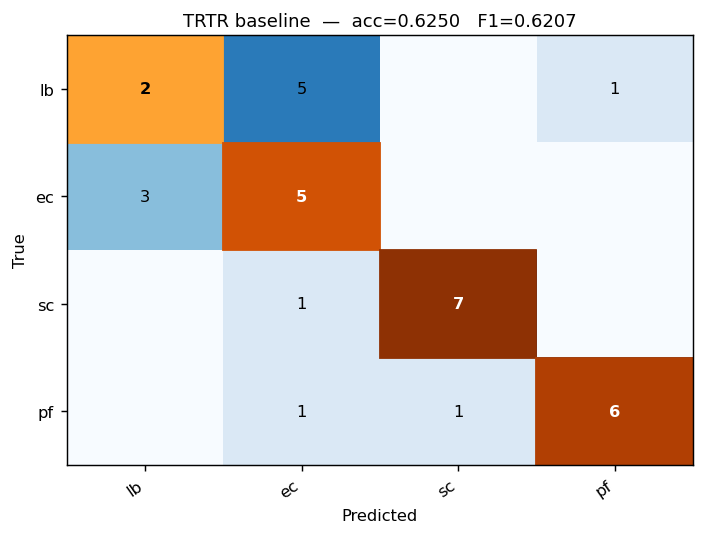

In [36]:
print("Training TRTR …")
TRTR_METRICS = train_eval(X_tr, y_tr, X_te, y_te)
TRTR_ACC     = TRTR_METRICS["accuracy"]

print_metrics_table(TRTR_METRICS, "TRTR — Train Real / Test Real  (baseline)")

n = len(LABEL_NAMES)
fig, ax = plt.subplots(figsize=(n*1.0 + 1.5, n*0.85 + 0.8))
draw_cm(ax, TRTR_METRICS["cm"], LABEL_NAMES,
        f"TRTR baseline  —  acc={TRTR_ACC:.4f}   F1={TRTR_METRICS['f1_macro']:.4f}")
plt.tight_layout(); plt.show()


---
## Model: cWGAN-GP

In [37]:
# ── load synthetic cache ─────────────────────────────────────────────────────
_path_cwgan_gp = MODEL_CACHES["cWGAN-GP"]
if not _path_cwgan_gp or not Path(_path_cwgan_gp).exists():
    print(f"  Skipping cWGAN-GP: cache not found at {_path_cwgan_gp}")
    X_syn_cwgan_gp = y_syn_cwgan_gp = None
else:
    X_syn_cwgan_gp, y_syn_cwgan_gp, _ = load_cache(_path_cwgan_gp, target_shape=CANON, pure_only=True)
    print(f"  Class distribution: {dict(Counter(y_syn_cwgan_gp))}")


  Loaded synthetic_cwgan_gp.h5: 640 pure-culture samples  shape=(690, 128) 
  Class distribution: {np.str_('lb'): 160, np.str_('ec'): 160, np.str_('sc'): 160, np.str_('pf'): 160}


Ratio sweep (cWGAN-GP)  N_seeds=5 × 10 ratios …

──────────────────────────────────────────────────────────────
  cWGAN-GP  TSTR+  best ratio=2.0x  (+170 synthetic)
  Accuracy : 0.8125   F1-macro : 0.8143
──────────────────────────────────────────────────────────────
  Class       TP    TN    FP    FN    Prec   Rec    F1
  ──────────────────────────────────────────────────────
  lb           6    23     1     2   0.857 0.750 0.800
  ec           6    23     1     2   0.857 0.750 0.800
  sc           6    24     0     2   1.000 0.750 0.857
  pf           8    20     4     0   0.667 1.000 0.800



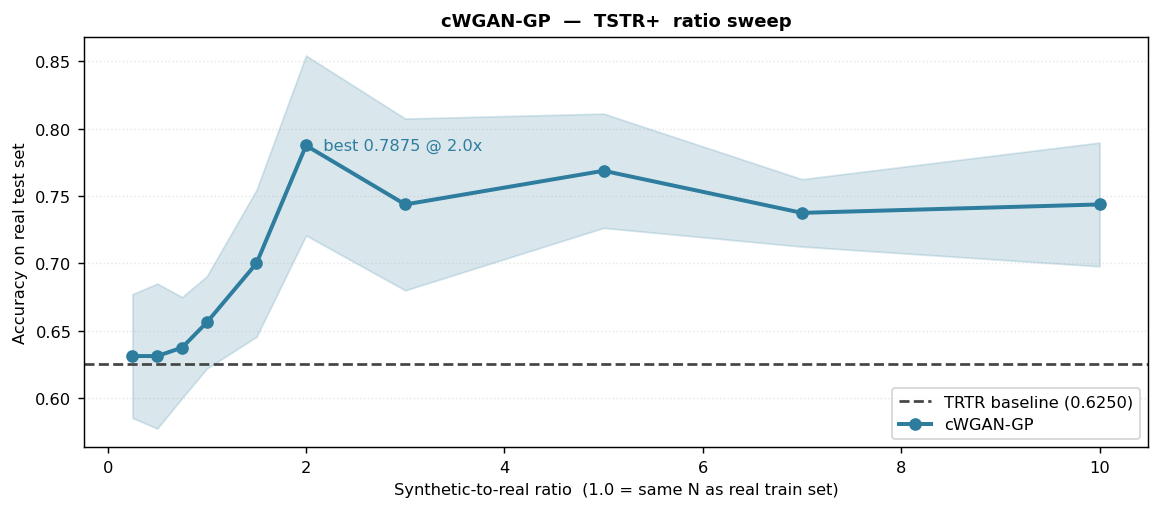

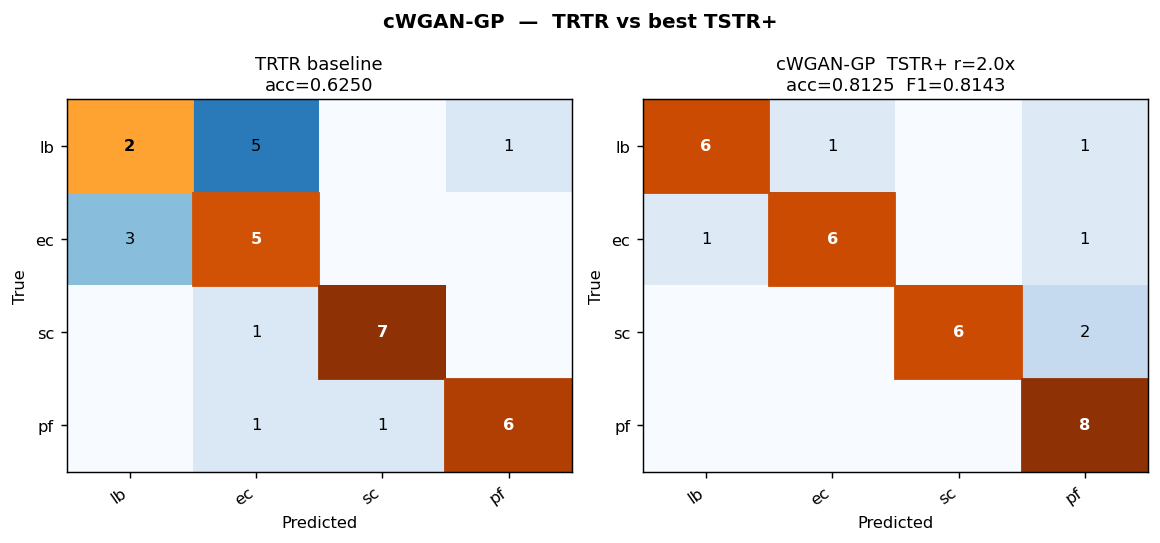

In [38]:
# ── ratio sweep + metrics + plots ────────────────────────────────────────────
if X_syn_cwgan_gp is None:
    print("Skipped.")
else:
    # ratio sweep
    print(f"Ratio sweep (cWGAN-GP)  N_seeds={N_SEEDS} × {len(RATIOS)} ratios …")
    _sweep_cwgan_gp = ratio_sweep(X_tr, y_tr, X_syn_cwgan_gp, y_syn_cwgan_gp, X_te, y_te)
    ALL_SWEEPS["cWGAN-GP"] = _sweep_cwgan_gp

    # find best ratio, re-train for full metrics
    _best_r_cwgan_gp = max(_sweep_cwgan_gp, key=lambda r: _sweep_cwgan_gp[r][0])
    _ns = int(len(X_tr) * _best_r_cwgan_gp)
    np.random.seed(0)
    _idx = (np.random.choice(len(X_syn_cwgan_gp), _ns, replace=False)
            if _ns <= len(X_syn_cwgan_gp)
            else np.random.choice(len(X_syn_cwgan_gp), _ns, replace=True))
    _Xa = np.concatenate([X_tr,  X_syn_cwgan_gp[_idx]])
    _ya = np.concatenate([y_tr, y_syn_cwgan_gp[_idx]])
    _best_m_cwgan_gp = train_eval(_Xa, _ya, X_te, y_te)
    ALL_BEST_M["cWGAN-GP"] = _best_m_cwgan_gp
    ALL_BEST_R["cWGAN-GP"] = _best_r_cwgan_gp

    print_metrics_table(_best_m_cwgan_gp,
        f"cWGAN-GP  TSTR+  best ratio={_best_r_cwgan_gp}x  "
        f"(+{int(len(X_tr)*_best_r_cwgan_gp)} synthetic)")

    # ── plot 1: ratio sweep ───────────────────────────────────────────────────
    plot_ratio_sweep_single(_sweep_cwgan_gp, "cWGAN-GP", "#2e7d9e", TRTR_ACC)

    # ── plot 2: TRTR vs TSTR+ confusion matrices side by side ─────────────────
    n = len(LABEL_NAMES)
    fig, axes = plt.subplots(1, 2, figsize=(n*2.0+1, n*0.85+0.8))
    draw_cm(axes[0], TRTR_METRICS["cm"], LABEL_NAMES,
            f"TRTR baseline\nacc={TRTR_ACC:.4f}")
    draw_cm(axes[1], _best_m_cwgan_gp["cm"], LABEL_NAMES,
            f"cWGAN-GP  TSTR+ r={_best_r_cwgan_gp}x\n"
            f"acc={_best_m_cwgan_gp['accuracy']:.4f}  "
            f"F1={_best_m_cwgan_gp['f1_macro']:.4f}")
    fig.suptitle("cWGAN-GP  —  TRTR vs best TSTR+", fontweight="bold", fontsize=11)
    plt.tight_layout(); plt.show()


---
## Model: cWGAN

In [39]:
# ── load synthetic cache ─────────────────────────────────────────────────────
_path_cwgan = MODEL_CACHES["cWGAN"]
if not _path_cwgan or not Path(_path_cwgan).exists():
    print(f"  Skipping cWGAN: cache not found at {_path_cwgan}")
    X_syn_cwgan = y_syn_cwgan = None
else:
    X_syn_cwgan, y_syn_cwgan, _ = load_cache(_path_cwgan, target_shape=CANON, pure_only=True)
    print(f"  Class distribution: {dict(Counter(y_syn_cwgan))}")


  Loaded synthetic_cwgan.h5: 640 pure-culture samples  shape=(690, 128) 
  Class distribution: {np.str_('lb'): 160, np.str_('ec'): 160, np.str_('sc'): 160, np.str_('pf'): 160}


Ratio sweep (cWGAN)  N_seeds=5 × 10 ratios …

──────────────────────────────────────────────────────────────
  cWGAN  TSTR+  best ratio=0.25x  (+21 synthetic)
  Accuracy : 0.6250   F1-macro : 0.6063
──────────────────────────────────────────────────────────────
  Class       TP    TN    FP    FN    Prec   Rec    F1
  ──────────────────────────────────────────────────────
  lb           2    21     3     6   0.400 0.250 0.308
  ec           5    20     4     3   0.556 0.625 0.588
  sc           7    22     2     1   0.778 0.875 0.824
  pf           6    21     3     2   0.667 0.750 0.706



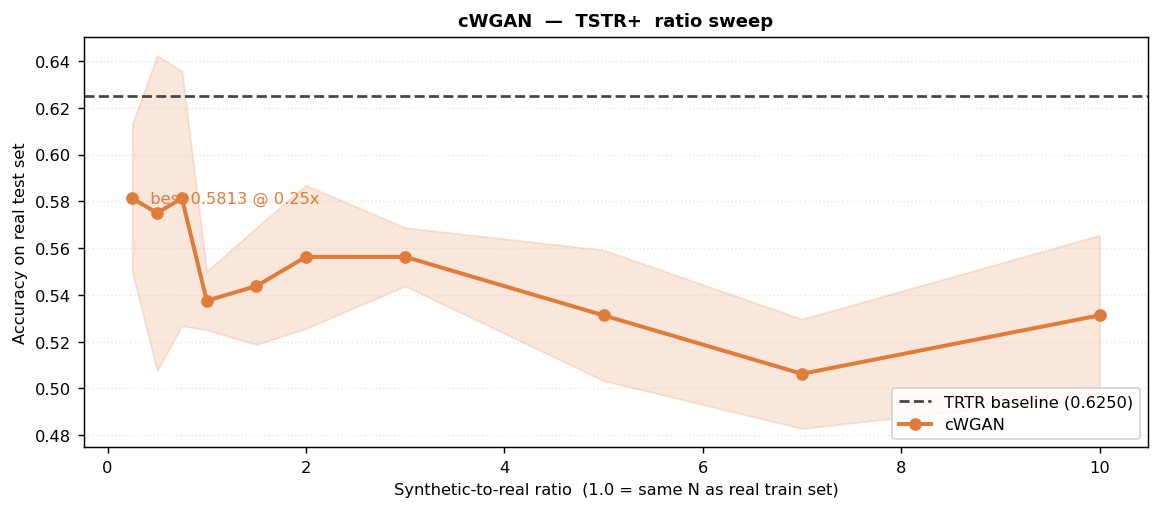

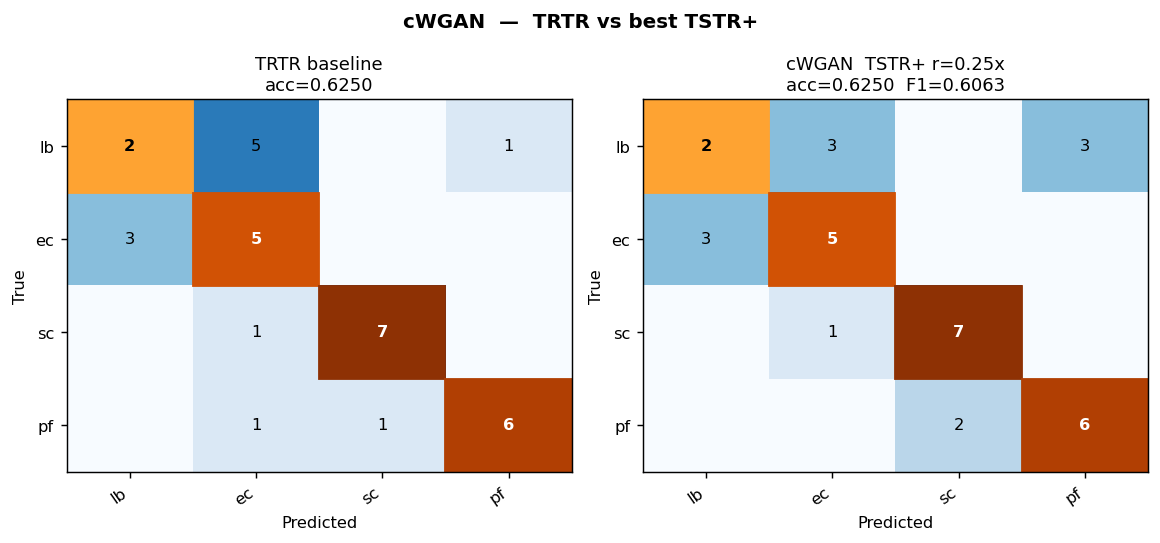

In [40]:
# ── ratio sweep + metrics + plots ────────────────────────────────────────────
if X_syn_cwgan is None:
    print("Skipped.")
else:
    # ratio sweep
    print(f"Ratio sweep (cWGAN)  N_seeds={N_SEEDS} × {len(RATIOS)} ratios …")
    _sweep_cwgan = ratio_sweep(X_tr, y_tr, X_syn_cwgan, y_syn_cwgan, X_te, y_te)
    ALL_SWEEPS["cWGAN"] = _sweep_cwgan

    # find best ratio, re-train for full metrics
    _best_r_cwgan = max(_sweep_cwgan, key=lambda r: _sweep_cwgan[r][0])
    _ns = int(len(X_tr) * _best_r_cwgan)
    np.random.seed(0)
    _idx = (np.random.choice(len(X_syn_cwgan), _ns, replace=False)
            if _ns <= len(X_syn_cwgan)
            else np.random.choice(len(X_syn_cwgan), _ns, replace=True))
    _Xa = np.concatenate([X_tr,  X_syn_cwgan[_idx]])
    _ya = np.concatenate([y_tr, y_syn_cwgan[_idx]])
    _best_m_cwgan = train_eval(_Xa, _ya, X_te, y_te)
    ALL_BEST_M["cWGAN"] = _best_m_cwgan
    ALL_BEST_R["cWGAN"] = _best_r_cwgan

    print_metrics_table(_best_m_cwgan,
        f"cWGAN  TSTR+  best ratio={_best_r_cwgan}x  "
        f"(+{int(len(X_tr)*_best_r_cwgan)} synthetic)")

    # ── plot 1: ratio sweep ───────────────────────────────────────────────────
    plot_ratio_sweep_single(_sweep_cwgan, "cWGAN", "#e07b39", TRTR_ACC)

    # ── plot 2: TRTR vs TSTR+ confusion matrices side by side ─────────────────
    n = len(LABEL_NAMES)
    fig, axes = plt.subplots(1, 2, figsize=(n*2.0+1, n*0.85+0.8))
    draw_cm(axes[0], TRTR_METRICS["cm"], LABEL_NAMES,
            f"TRTR baseline\nacc={TRTR_ACC:.4f}")
    draw_cm(axes[1], _best_m_cwgan["cm"], LABEL_NAMES,
            f"cWGAN  TSTR+ r={_best_r_cwgan}x\n"
            f"acc={_best_m_cwgan['accuracy']:.4f}  "
            f"F1={_best_m_cwgan['f1_macro']:.4f}")
    fig.suptitle("cWGAN  —  TRTR vs best TSTR+", fontweight="bold", fontsize=11)
    plt.tight_layout(); plt.show()


---
## Model: cGAN

In [41]:
# ── load synthetic cache ─────────────────────────────────────────────────────
_path_cgan = MODEL_CACHES["cGAN"]
if not _path_cgan or not Path(_path_cgan).exists():
    print(f"  Skipping cGAN: cache not found at {_path_cgan}")
    X_syn_cgan = y_syn_cgan = None
else:
    X_syn_cgan, y_syn_cgan, _ = load_cache(_path_cgan, target_shape=CANON, pure_only=True)
    print(f"  Class distribution: {dict(Counter(y_syn_cgan))}")


  Loaded synthetic_cgan.h5: 640 pure-culture samples  shape=(690, 128) 
  Class distribution: {np.str_('lb'): 160, np.str_('ec'): 160, np.str_('sc'): 160, np.str_('pf'): 160}


Ratio sweep (cGAN)  N_seeds=5 × 10 ratios …

──────────────────────────────────────────────────────────────
  cGAN  TSTR+  best ratio=1.5x  (+127 synthetic)
  Accuracy : 0.6250   F1-macro : 0.6090
──────────────────────────────────────────────────────────────
  Class       TP    TN    FP    FN    Prec   Rec    F1
  ──────────────────────────────────────────────────────
  lb           2    23     1     6   0.667 0.250 0.364
  ec           7    17     7     1   0.500 0.875 0.636
  sc           5    24     0     3   1.000 0.625 0.769
  pf           6    20     4     2   0.600 0.750 0.667



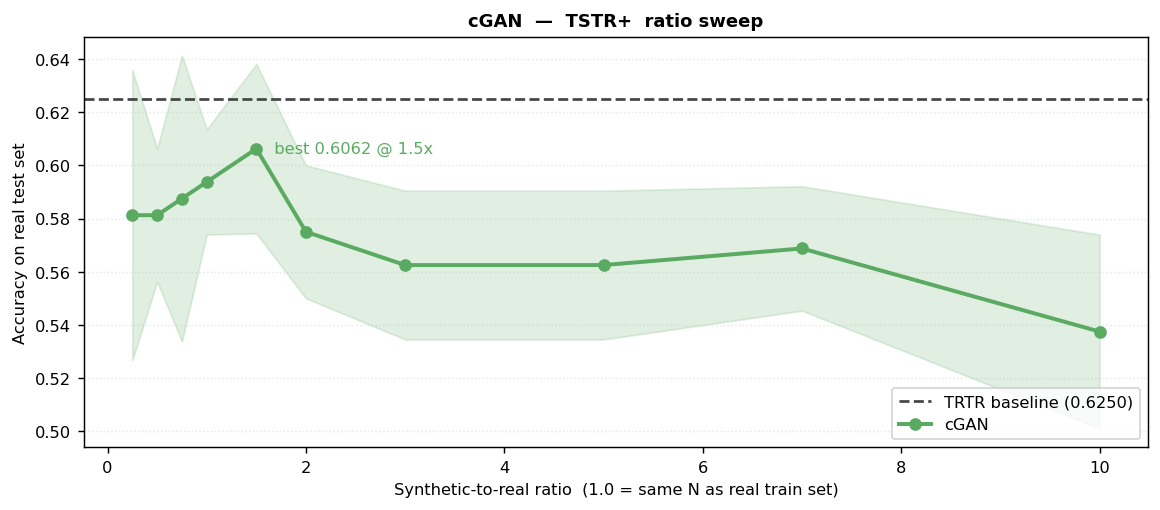

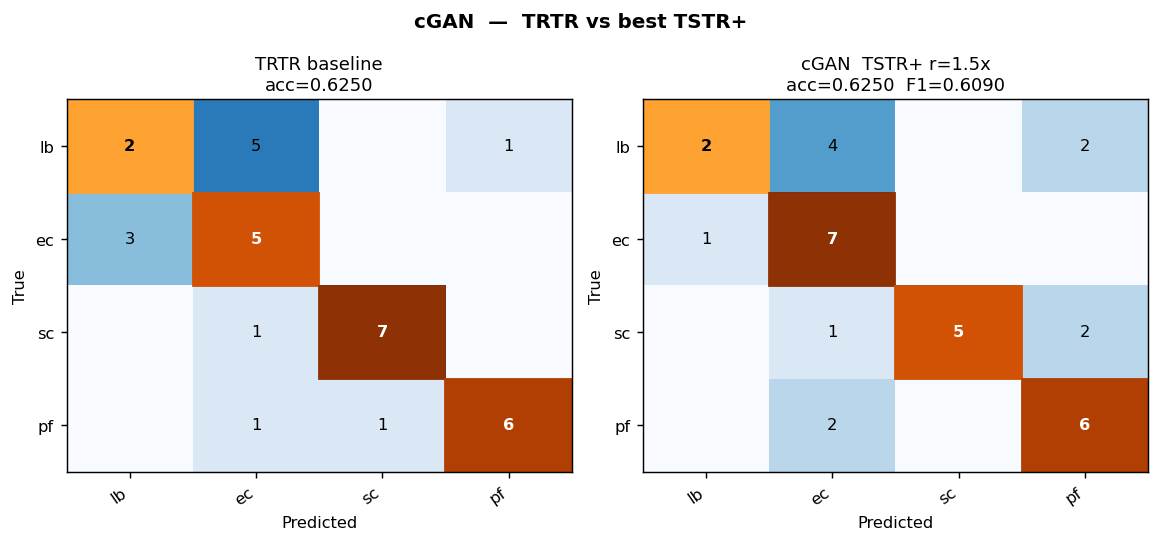

In [42]:
# ── ratio sweep + metrics + plots ────────────────────────────────────────────
if X_syn_cgan is None:
    print("Skipped.")
else:
    # ratio sweep
    print(f"Ratio sweep (cGAN)  N_seeds={N_SEEDS} × {len(RATIOS)} ratios …")
    _sweep_cgan = ratio_sweep(X_tr, y_tr, X_syn_cgan, y_syn_cgan, X_te, y_te)
    ALL_SWEEPS["cGAN"] = _sweep_cgan

    # find best ratio, re-train for full metrics
    _best_r_cgan = max(_sweep_cgan, key=lambda r: _sweep_cgan[r][0])
    _ns = int(len(X_tr) * _best_r_cgan)
    np.random.seed(0)
    _idx = (np.random.choice(len(X_syn_cgan), _ns, replace=False)
            if _ns <= len(X_syn_cgan)
            else np.random.choice(len(X_syn_cgan), _ns, replace=True))
    _Xa = np.concatenate([X_tr,  X_syn_cgan[_idx]])
    _ya = np.concatenate([y_tr, y_syn_cgan[_idx]])
    _best_m_cgan = train_eval(_Xa, _ya, X_te, y_te)
    ALL_BEST_M["cGAN"] = _best_m_cgan
    ALL_BEST_R["cGAN"] = _best_r_cgan

    print_metrics_table(_best_m_cgan,
        f"cGAN  TSTR+  best ratio={_best_r_cgan}x  "
        f"(+{int(len(X_tr)*_best_r_cgan)} synthetic)")

    # ── plot 1: ratio sweep ───────────────────────────────────────────────────
    plot_ratio_sweep_single(_sweep_cgan, "cGAN", "#5aab61", TRTR_ACC)

    # ── plot 2: TRTR vs TSTR+ confusion matrices side by side ─────────────────
    n = len(LABEL_NAMES)
    fig, axes = plt.subplots(1, 2, figsize=(n*2.0+1, n*0.85+0.8))
    draw_cm(axes[0], TRTR_METRICS["cm"], LABEL_NAMES,
            f"TRTR baseline\nacc={TRTR_ACC:.4f}")
    draw_cm(axes[1], _best_m_cgan["cm"], LABEL_NAMES,
            f"cGAN  TSTR+ r={_best_r_cgan}x\n"
            f"acc={_best_m_cgan['accuracy']:.4f}  "
            f"F1={_best_m_cgan['f1_macro']:.4f}")
    fig.suptitle("cGAN  —  TRTR vs best TSTR+", fontweight="bold", fontsize=11)
    plt.tight_layout(); plt.show()


---
## Model: WGAN-GP

In [43]:
# ── load synthetic cache ─────────────────────────────────────────────────────
_path_wgan_gp = MODEL_CACHES["WGAN-GP"]
if not _path_wgan_gp or not Path(_path_wgan_gp).exists():
    print(f"  Skipping WGAN-GP: cache not found at {_path_wgan_gp}")
    X_syn_wgan_gp = y_syn_wgan_gp = None
else:
    X_syn_wgan_gp, y_syn_wgan_gp, _ = load_cache(_path_wgan_gp, target_shape=CANON, pure_only=True)
    print(f"  Class distribution: {dict(Counter(y_syn_wgan_gp))}")


  Loaded synthetic_wgan_gp.h5: 640 pure-culture samples  shape=(690, 128) 
  Class distribution: {np.str_('lb'): 160, np.str_('ec'): 160, np.str_('sc'): 160, np.str_('pf'): 160}


Ratio sweep (WGAN-GP)  N_seeds=5 × 10 ratios …

──────────────────────────────────────────────────────────────
  WGAN-GP  TSTR+  best ratio=0.25x  (+21 synthetic)
  Accuracy : 0.5938   F1-macro : 0.5809
──────────────────────────────────────────────────────────────
  Class       TP    TN    FP    FN    Prec   Rec    F1
  ──────────────────────────────────────────────────────
  lb           1    21     3     7   0.250 0.125 0.167
  ec           5    16     8     3   0.385 0.625 0.476
  sc           6    24     0     2   1.000 0.750 0.857
  pf           7    22     2     1   0.778 0.875 0.824



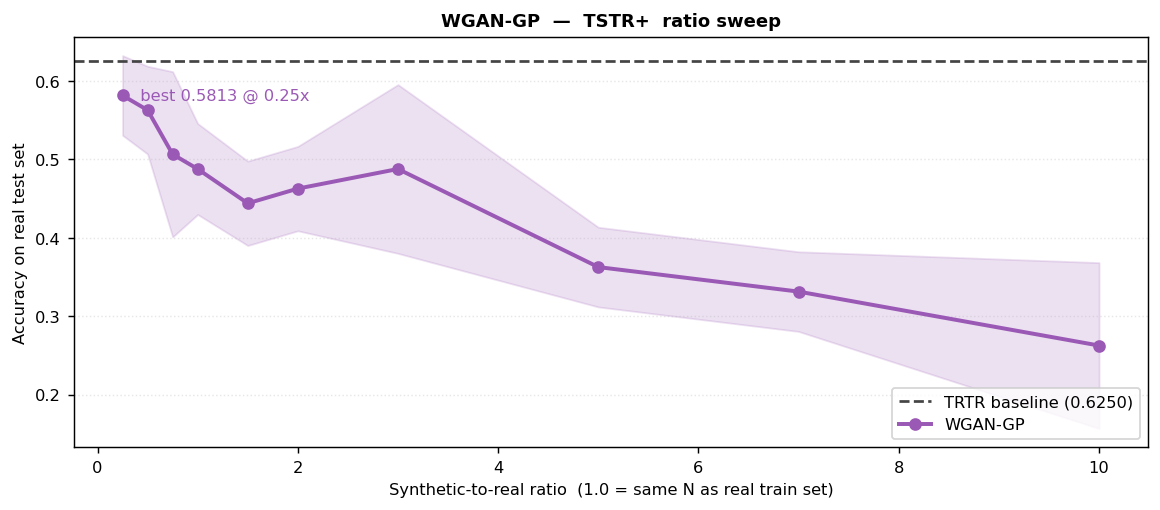

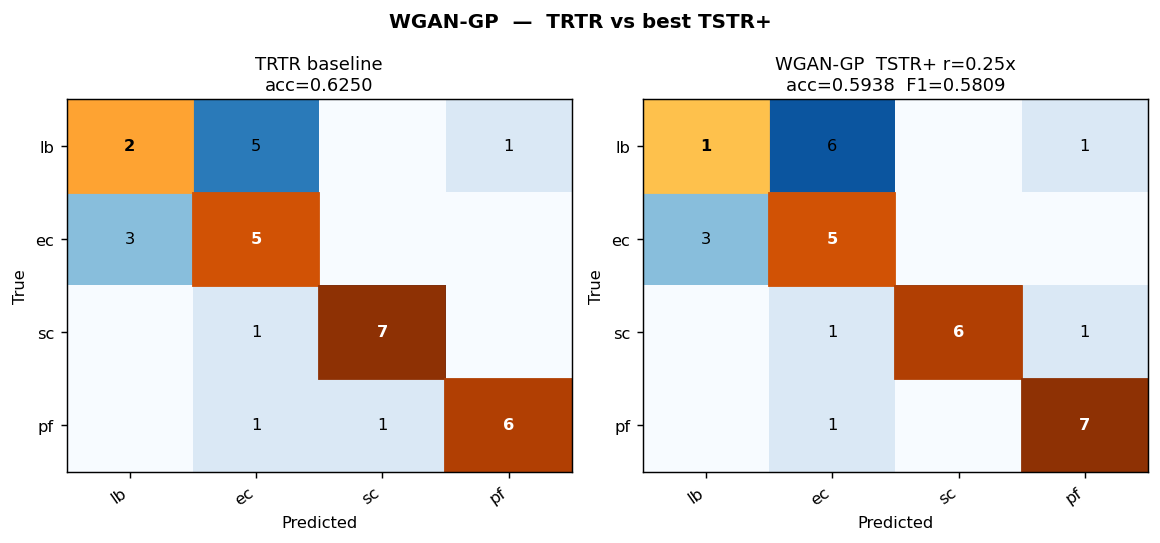

In [44]:
# ── ratio sweep + metrics + plots ────────────────────────────────────────────
if X_syn_wgan_gp is None:
    print("Skipped.")
else:
    # ratio sweep
    print(f"Ratio sweep (WGAN-GP)  N_seeds={N_SEEDS} × {len(RATIOS)} ratios …")
    _sweep_wgan_gp = ratio_sweep(X_tr, y_tr, X_syn_wgan_gp, y_syn_wgan_gp, X_te, y_te)
    ALL_SWEEPS["WGAN-GP"] = _sweep_wgan_gp

    # find best ratio, re-train for full metrics
    _best_r_wgan_gp = max(_sweep_wgan_gp, key=lambda r: _sweep_wgan_gp[r][0])
    _ns = int(len(X_tr) * _best_r_wgan_gp)
    np.random.seed(0)
    _idx = (np.random.choice(len(X_syn_wgan_gp), _ns, replace=False)
            if _ns <= len(X_syn_wgan_gp)
            else np.random.choice(len(X_syn_wgan_gp), _ns, replace=True))
    _Xa = np.concatenate([X_tr,  X_syn_wgan_gp[_idx]])
    _ya = np.concatenate([y_tr, y_syn_wgan_gp[_idx]])
    _best_m_wgan_gp = train_eval(_Xa, _ya, X_te, y_te)
    ALL_BEST_M["WGAN-GP"] = _best_m_wgan_gp
    ALL_BEST_R["WGAN-GP"] = _best_r_wgan_gp

    print_metrics_table(_best_m_wgan_gp,
        f"WGAN-GP  TSTR+  best ratio={_best_r_wgan_gp}x  "
        f"(+{int(len(X_tr)*_best_r_wgan_gp)} synthetic)")

    # ── plot 1: ratio sweep ───────────────────────────────────────────────────
    plot_ratio_sweep_single(_sweep_wgan_gp, "WGAN-GP", "#9b59b6", TRTR_ACC)

    # ── plot 2: TRTR vs TSTR+ confusion matrices side by side ─────────────────
    n = len(LABEL_NAMES)
    fig, axes = plt.subplots(1, 2, figsize=(n*2.0+1, n*0.85+0.8))
    draw_cm(axes[0], TRTR_METRICS["cm"], LABEL_NAMES,
            f"TRTR baseline\nacc={TRTR_ACC:.4f}")
    draw_cm(axes[1], _best_m_wgan_gp["cm"], LABEL_NAMES,
            f"WGAN-GP  TSTR+ r={_best_r_wgan_gp}x\n"
            f"acc={_best_m_wgan_gp['accuracy']:.4f}  "
            f"F1={_best_m_wgan_gp['f1_macro']:.4f}")
    fig.suptitle("WGAN-GP  —  TRTR vs best TSTR+", fontweight="bold", fontsize=11)
    plt.tight_layout(); plt.show()


---
## 5 · Cross-model comparison
Run after all model cells have executed.

In [45]:
# ── summary table ────────────────────────────────────────────────────────────
if not ALL_BEST_M:
    print("No models evaluated yet.")
else:
    rows = []
    for model in ALL_BEST_M:
        bm = ALL_BEST_M[model]
        br = ALL_BEST_R[model]
        rows.append({
            "Model":      model,
            "TRTR acc":   round(TRTR_ACC, 4),
            "Best acc":   round(bm["accuracy"], 4),
            "Best F1":    round(bm["f1_macro"], 4),
            "Best ratio": f"{br}x",
            "Δ acc":      round(bm["accuracy"] - TRTR_ACC, 4),
            "% of TRTR":  round(bm["accuracy"] / TRTR_ACC * 100, 1),
        })
    df = pd.DataFrame(rows).set_index("Model")
    display(df.style
            .background_gradient(cmap="RdYlGn", subset=["Best acc","Best F1","% of TRTR"])
            .format({"Δ acc": "{:+.4f}"}))


,TRTR acc,Best acc,Best F1,Best ratio,Δ acc,% of TRTR
Model,,,,,,
cWGAN-GP,0.625000,0.812500,0.814300,2.0x,+0.1875,130.000000
cWGAN,0.625000,0.625000,0.606300,0.25x,+0.0000,100.000000
cGAN,0.625000,0.625000,0.609000,1.5x,+0.0000,100.000000
WGAN-GP,0.625000,0.593800,0.580900,0.25x,-0.0312,95.000000


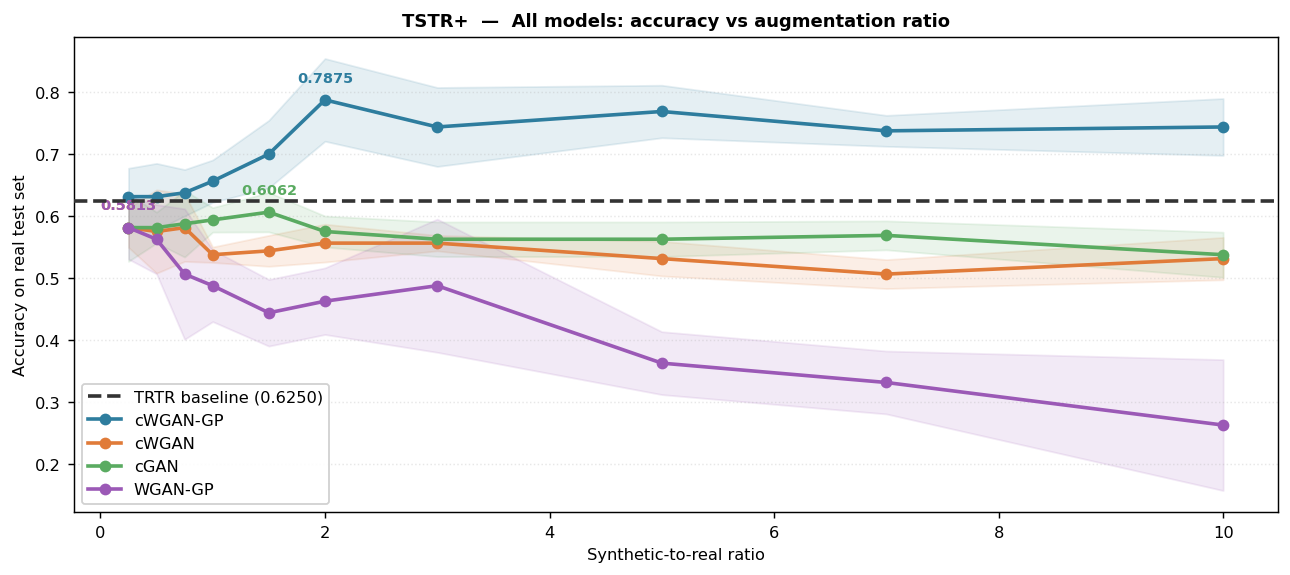

In [46]:
# ── all models ratio sweep on one chart ──────────────────────────────────────
if ALL_SWEEPS:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.axhline(TRTR_ACC, color="#333", ls="--", lw=2,
               label=f"TRTR baseline ({TRTR_ACC:.4f})", zorder=6)

    for model, sweep in ALL_SWEEPS.items():
        rv  = list(sweep.keys())
        mn  = [sweep[r][0] for r in rv]
        sd  = [sweep[r][1] for r in rv]
        col = MODEL_COLORS[model]
        ax.fill_between(rv, [m-s for m,s in zip(mn,sd)],
                            [m+s for m,s in zip(mn,sd)],
                        alpha=0.12, color=col)
        ax.plot(rv, mn, "o-", color=col, lw=2, ms=5.5, label=model)
        pi = int(np.argmax(mn))
        ax.annotate(f"{mn[pi]:.4f}", xy=(rv[pi], mn[pi]),
                    xytext=(0, 10), textcoords="offset points",
                    fontsize=8, ha="center", color=col, fontweight="bold")

    ax.set_xlabel("Synthetic-to-real ratio")
    ax.set_ylabel("Accuracy on real test set")
    ax.set_title("TSTR+  —  All models: accuracy vs augmentation ratio",
                 fontweight="bold")
    ax.legend(framealpha=0.9)
    ax.grid(axis="y", alpha=0.3, ls=":")
    plt.tight_layout(); plt.show()


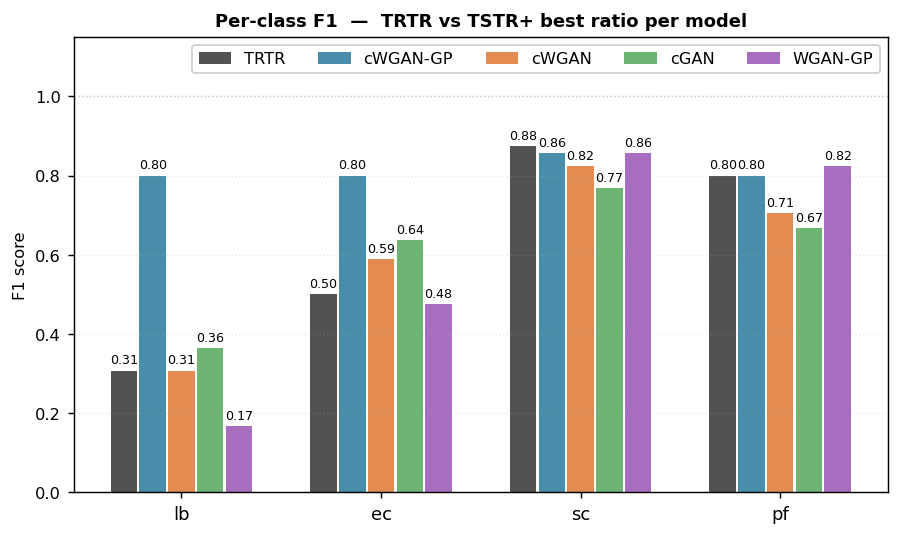

In [47]:
# ── per-class F1 grouped bar chart ───────────────────────────────────────────
if ALL_BEST_M:
    models_ord = ["TRTR"] + list(ALL_BEST_M.keys())
    n_cls = len(LABEL_NAMES); n_mod = len(models_ord)
    w = 0.72 / n_mod; x = np.arange(n_cls)

    fig, ax = plt.subplots(figsize=(max(7, n_cls*1.6), 4.2))
    for i, model in enumerate(models_ord):
        m   = TRTR_METRICS if model == "TRTR" else ALL_BEST_M[model]
        f1s = [m["per_class"].get(c, {}).get("f1", 0.0) for c in LABEL_NAMES]
        col = "#3a3a3a" if model == "TRTR" else MODEL_COLORS[model]
        bars = ax.bar(x + i*w - (n_mod-1)*w/2, f1s,
                      w*0.92, label=model, color=col, alpha=0.88)
        for bar, v in zip(bars, f1s):
            if v > 0.05:
                ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
                        f"{v:.2f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(LABEL_NAMES, fontsize=10)
    ax.set_ylabel("F1 score"); ax.set_ylim(0, 1.15)
    ax.axhline(1.0, color="#ccc", ls=":", lw=0.8)
    ax.set_title("Per-class F1  —  TRTR vs TSTR+ best ratio per model",
                 fontweight="bold")
    ax.legend(ncol=min(n_mod, 5), framealpha=0.9, loc="upper right")
    ax.grid(axis="y", alpha=0.25, ls=":")
    plt.tight_layout(); plt.show()


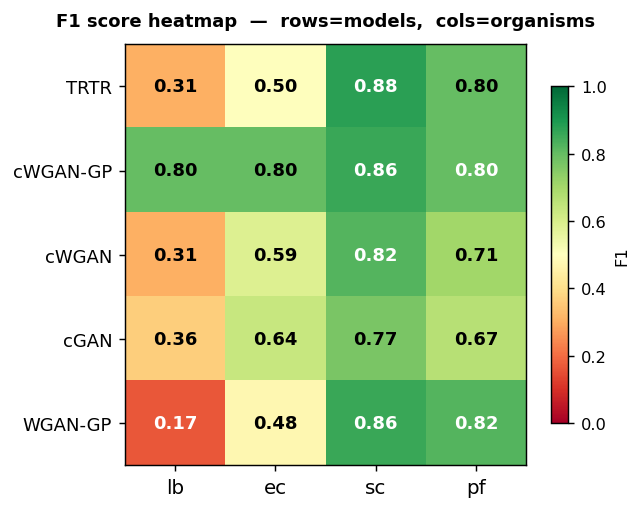

In [48]:
# ── F1 heatmap: rows=models, cols=classes ────────────────────────────────────
if ALL_BEST_M:
    models_ord = ["TRTR"] + list(ALL_BEST_M.keys())
    data = []
    for model in models_ord:
        m = TRTR_METRICS if model == "TRTR" else ALL_BEST_M[model]
        data.append([m["per_class"].get(c, {}).get("f1", 0.0) for c in LABEL_NAMES])
    mat = np.array(data)

    fig, ax = plt.subplots(figsize=(max(5, len(LABEL_NAMES)*1.1),
                                    max(2.5, len(models_ord)*0.8)))
    im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, label="F1", shrink=0.8)
    for i in range(len(models_ord)):
        for j in range(len(LABEL_NAMES)):
            v  = mat[i, j]
            fc = "black" if 0.2 < v < 0.8 else "white"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=10, color=fc, fontweight="bold")
    ax.set_xticks(range(len(LABEL_NAMES)))
    ax.set_xticklabels(LABEL_NAMES, fontsize=11)
    ax.set_yticks(range(len(models_ord)))
    ax.set_yticklabels(models_ord, fontsize=10)
    ax.set_title("F1 score heatmap  —  rows=models,  cols=organisms",
                 fontweight="bold", pad=10)
    plt.tight_layout(); plt.show()


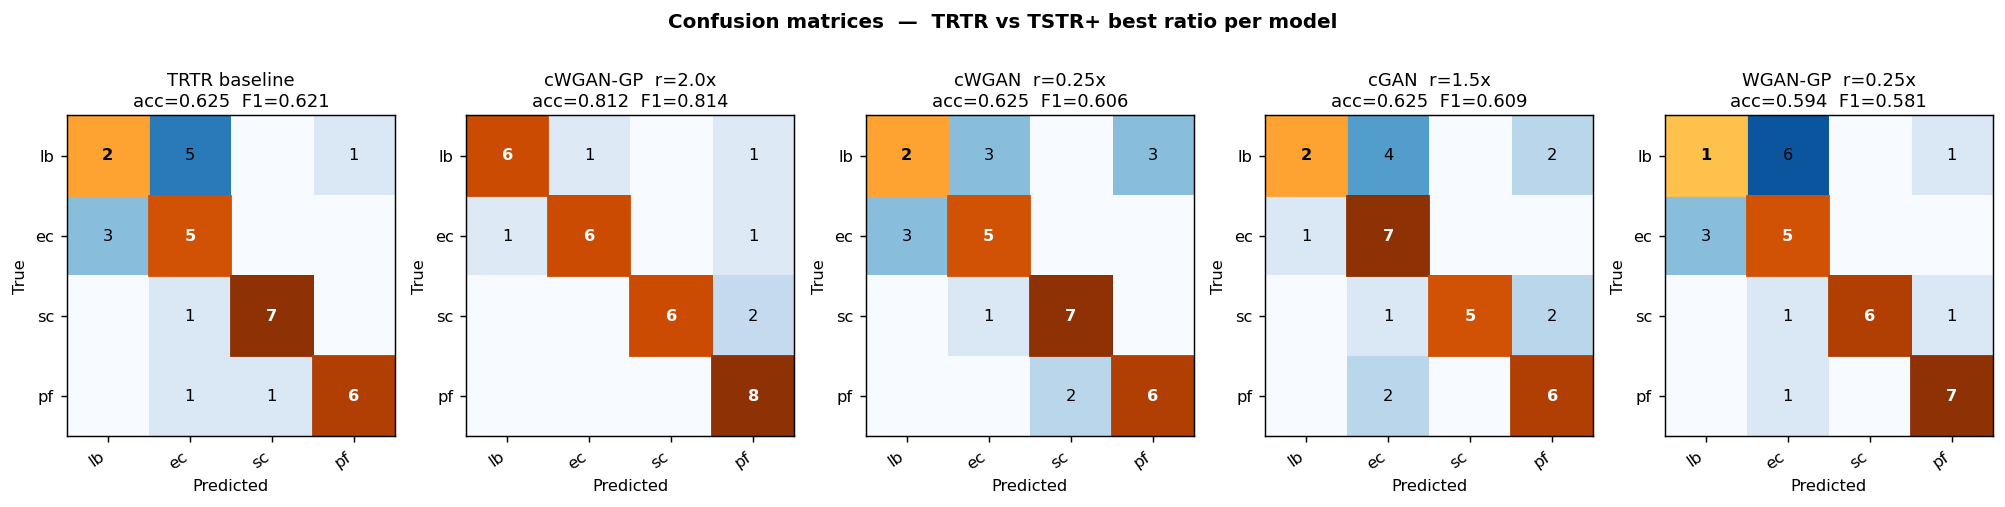

In [49]:
# ── all confusion matrices side by side ──────────────────────────────────────
if ALL_BEST_M:
    entries = [("TRTR", TRTR_METRICS)] + list(ALL_BEST_M.items())
    n_plots = len(entries); n_lbl = len(LABEL_NAMES)
    csz = max(3.0, n_lbl*0.75)
    fig, axes = plt.subplots(1, n_plots,
                              figsize=(csz*n_plots + 0.5, csz + 0.8))
    if n_plots == 1: axes = [axes]
    for ax, (model, m) in zip(axes, entries):
        br  = ALL_BEST_R.get(model, "")
        sub = ("TRTR baseline" if model == "TRTR"
               else f"{model}  r={br}x")
        draw_cm(ax, m["cm"], LABEL_NAMES,
                f"{sub}\nacc={m['accuracy']:.3f}  F1={m['f1_macro']:.3f}")
    fig.suptitle("Confusion matrices  —  TRTR vs TSTR+ best ratio per model",
                 fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()
